In [1]:
# Gerekli kütüphaneleri kurma
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [2]:
import os
from IPython.display import display, Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="EjlgDp1r4QIPQqhgOQdr")
project = rf.workspace("totetec").project("phone-detection-hl97v")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to phone-detection-1 in yolov8:: 100%|██████████| 1748/1748 [00:00<00:00, 3430.95it/s]


In [4]:
model = YOLO('yolov8n.pt')  # 'n' küçük model, daha hızlı eğitim için

100%|██████████| 6.25M/6.25M [00:00<00:00, 98.1MB/s]


In [5]:
# Model eğitimi
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,  # Epoch sayısı, performansa göre ayarlayın
    imgsz=640,   # Görüntü boyutu
    batch=16,    # Batch size, GPU belleğine göre ayarlayın
    name='samsung_iphone_model'  # Eğitim sonuçları için klasör adı
)


Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/phone-detection-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=samsung_iphone_model, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, sh

100%|██████████| 755k/755k [00:00<00:00, 20.0MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 103MB/s]


AMP: checks passed ✅


...

    100/100      4.29G      0.212       0.17     0.8991          7        640: 100%|██████████| 48/48 [00:11<00:00,  4.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  4.46it/s]

                   all         73         73      0.974      0.987      0.989      0.989



100 epochs completed in 0.379 hours.
Optimizer stripped from runs/detect/samsung_iphone_model/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/samsung_iphone_model/weights/best.pt, 6.3MB

Validating runs/detect/samsung_iphone_model/weights/best.pt...
Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  2.93it/s]


                   all         73         73      0.985      0.988      0.995      0.994
                iphone         39         39          1      0.976      0.995      0.995
               samsung         34         34       0.97          1      0.995      0.993
Speed: 0.2ms preprocess, 2.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to runs/detect/samsung_iphone_model


In [6]:
results = model.val()


Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/phone-detection-1/valid/labels.cache... 73 images, 0 backgrounds, 0 corrupt: 100%|██████████| 73/73 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:03<00:00,  1.57it/s]


                   all         73         73      0.985      0.988      0.995      0.994
                iphone         39         39          1      0.976      0.995      0.995
               samsung         34         34       0.97          1      0.995      0.993
Speed: 6.0ms preprocess, 12.8ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to runs/detect/samsung_iphone_model2



image 1/1 /content/phone-detection-1/test/images/IMG_1465_JPG.rf.67fd05b0567e16a4267bbf2bba3dfdf6.jpg: 640x640 1 iphone, 10.4ms
Speed: 4.0ms preprocess, 10.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


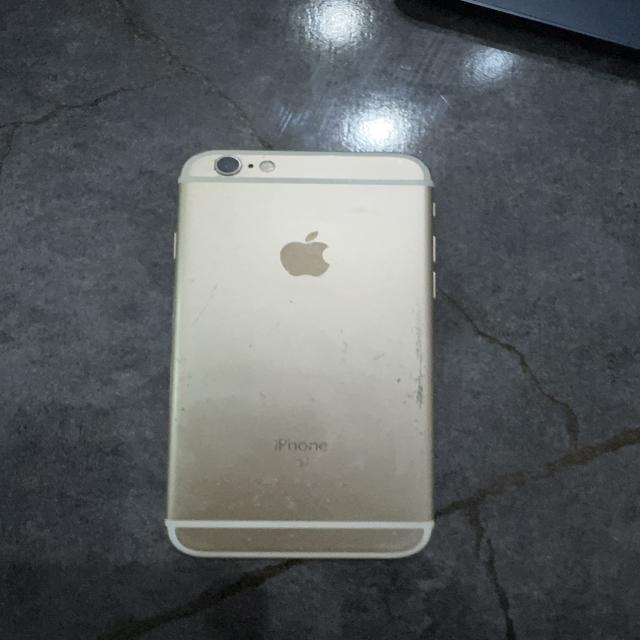

In [9]:
test_img = "/content/phone-detection-1/test/images/IMG_1465_JPG.rf.67fd05b0567e16a4267bbf2bba3dfdf6.jpg"  # Test görüntüsü
results = model.predict(test_img, conf=0.25)
display(Image(filename=test_img))


In [10]:
# Görselleştirme
res_plotted = results[0].plot()
from PIL import Image
import numpy as np
res_plotted_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
im = Image.fromarray(res_plotted_rgb)
im.show()

NameError: name 'cv2' is not defined

In [11]:
model.export(format="onnx")  # ONNX formatında dışa aktarır
print("Model başarıyla eğitildi ve dışa aktarıldı!")

Ultralytics 8.3.107 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)

PyTorch: starting from 'runs/detect/samsung_iphone_model/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 226.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 291.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.8/280.8 MB 222.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 158.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 205.3 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 15.7s, installed 3 packages: ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.17.0 opset 19

In [12]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [13]:
!cp -r /content/runs/detect/samsung_iphone_model/ /content/drive/MyDrive/samsung_iphone_model/
print("Eğitim sonuçları Drive'a kopyalandı!")

Eğitim sonuçları Drive'a kopyalandı!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')